In [1]:
import pandas as pd

In [2]:
data=pd.read_excel(r"D:\python\ml\live-ml-project\filter data of airport.xlsx")

In [3]:
data

,Unnamed: 0,Total_Stops,journey_month,journey_date,dep_hours,dep_minutes,Arrival_hour,Arrival_min,Duration_hr,Duration_min,...,Banglore.2,Banglore.3,Cochin,Delhi.2,Delhi.3,Hyderabad,Kolkata.2,Kolkata.3,New Delhi,Price
0,0,0,3,24,22,20,1,10,2,50,...,True,False,False,False,False,False,False,False,True,3897
1,1,2,5,1,5,50,13,15,7,25,...,False,True,False,False,False,False,True,False,False,7662
2,2,2,6,9,9,25,4,25,19,0,...,False,False,True,True,False,False,False,False,False,13882
3,3,1,5,12,18,5,23,30,5,25,...,False,True,False,False,False,False,True,False,False,6218
4,4,1,3,1,16,50,21,35,4,45,...,True,False,False,False,False,False,False,False,True,13302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,10678,0,4,9,19,55,22,25,2,30,...,False,True,False,False,False,False,True,False,False,4107
10678,10679,0,4,27,20,45,23,20,2,35,...,False,True,False,False,False,False,True,False,False,4145
10679,10680,0,4,27,8,20,11,20,3,0,...,True,False,False,False,True,False,False,False,False,7229
10680,10681,0,3,1,11,30,14,10,2,40,...,True,False,False,False,False,False,False,False,True,12648


In [4]:
x=data.drop("Price",axis=1)

In [5]:
y=data["Price"]

In [6]:
from sklearn.model_selection import train_test_split

In [197]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [199]:
from sklearn.linear_model import LogisticRegression

In [201]:
model=LogisticRegression()

In [202]:
model

LogisticRegression()

In [203]:
model.fit(x_train,y_train)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

model.predict(x_test)

In [205]:
model.score(x_train,y_train)

0.027551156881102046

In [206]:
model.score(x_test,y_test)

0.02527301092043682

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

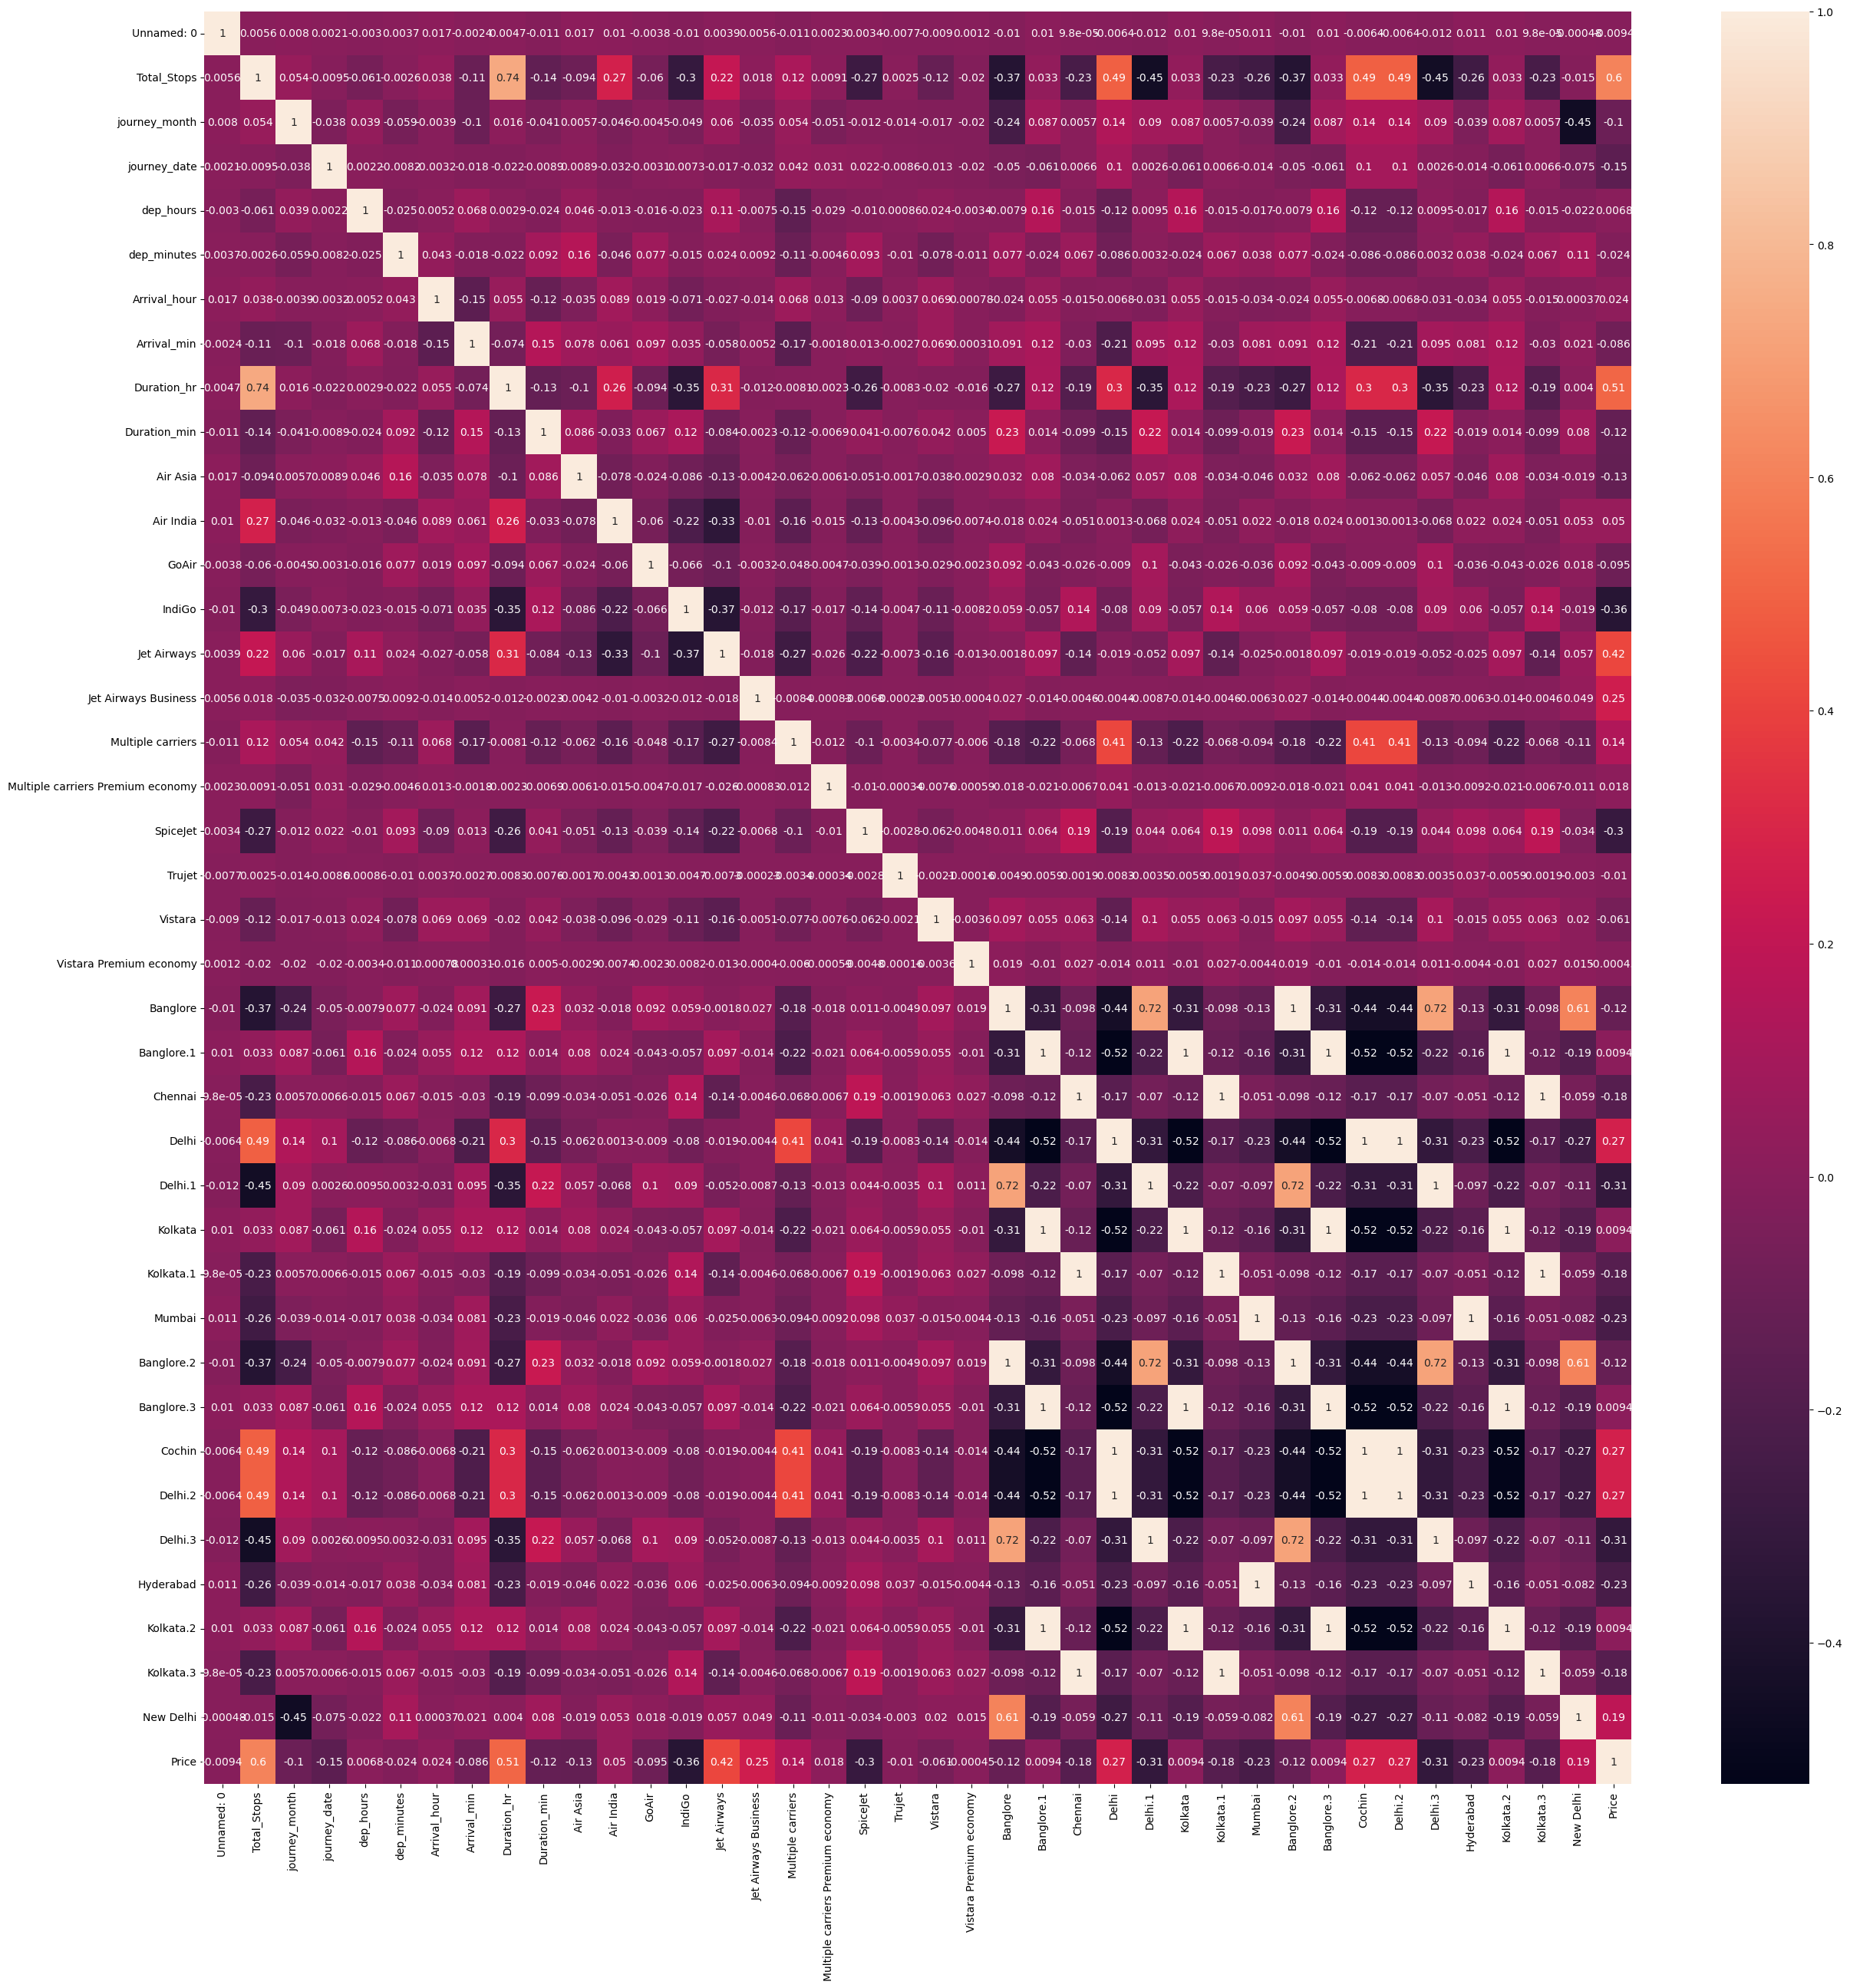

In [208]:
plt.figure(figsize=(30,30))
sns.heatmap(data.corr(),annot=True)

In [209]:
from sklearn.ensemble import ExtraTreesRegressor

In [210]:
model=ExtraTreesRegressor()

In [211]:
model.fit(x,y)

ExtraTreesRegressor()

In [212]:
model.feature_importances_

array([4.04864730e-02, 2.42360190e-01, 5.12532406e-02, 1.34792885e-01,
       2.27921365e-02, 2.04719764e-02, 2.62870683e-02, 1.88595552e-02,
       1.01606794e-01, 1.69280294e-02, 2.25209175e-03, 8.19748682e-03,
       1.71951372e-03, 1.79389581e-02, 1.30375291e-01, 6.44641704e-02,
       1.80706781e-02, 7.66297140e-04, 3.42596461e-03, 9.32308861e-05,
       4.51869273e-03, 8.18228092e-05, 6.88983099e-03, 1.17972245e-03,
       2.63587680e-04, 4.66746444e-03, 5.02248367e-03, 9.07893606e-04,
       3.44520457e-04, 6.59764925e-03, 5.26039484e-03, 1.01727196e-03,
       6.87431733e-03, 5.89460667e-03, 7.70333958e-03, 5.72631526e-03,
       1.08251749e-03, 3.27386323e-04, 1.24981512e-02])

In [213]:
a=pd.Series(model.feature_importances_,index=x.columns)

In [214]:
a

Unnamed: 0                           0.040486
Total_Stops                          0.242360
journey_month                        0.051253
journey_date                         0.134793
dep_hours                            0.022792
dep_minutes                          0.020472
Arrival_hour                         0.026287
Arrival_min                          0.018860
Duration_hr                          0.101607
Duration_min                         0.016928
Air Asia                             0.002252
Air India                            0.008197
GoAir                                0.001720
IndiGo                               0.017939
Jet Airways                          0.130375
Jet Airways Business                 0.064464
Multiple carriers                    0.018071
Multiple carriers Premium economy    0.000766
SpiceJet                             0.003426
Trujet                               0.000093
Vistara                              0.004519
Vistara Premium economy           

<Axes: >

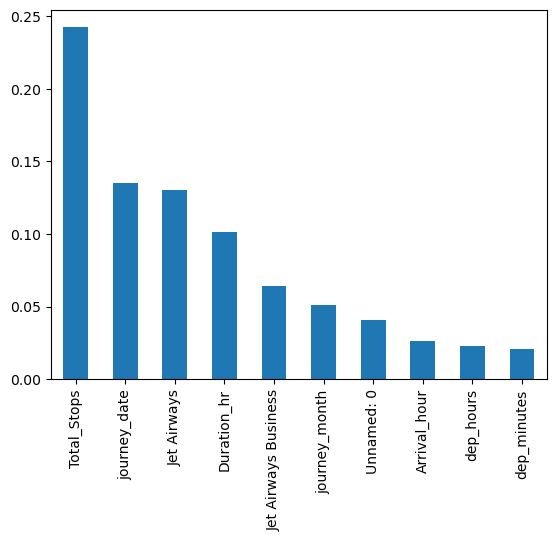

In [215]:
a.nlargest(10).plot(kind="bar")

In [216]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR

In [219]:
model = [DecisionTreeRegressor,SVR,RandomForestRegressor,KNeighborsRegressor,AdaBoostRegressor]

for i in model:
    reg = i()
    reg = reg.fit(x_train,y_train)
    print(i , 'accuracy',reg.score(x_test,y_test))

<class 'sklearn.tree._classes.DecisionTreeRegressor'> accuracy 0.6867882133903218
<class 'sklearn.svm._classes.SVR'> accuracy -0.021110220879601238
<class 'sklearn.ensemble._forest.RandomForestRegressor'> accuracy 0.8138473758739624
<class 'sklearn.neighbors._regression.KNeighborsRegressor'> accuracy -0.047034804779841455
<class 'sklearn.ensemble._weight_boosting.AdaBoostRegressor'> accuracy 0.2699560185808544


In [245]:
from sklearn.ensemble import RandomForestRegressor

In [247]:
model=RandomForestRegressor()

In [249]:
model

RandomForestRegressor()

In [251]:
model.fit(x_train,y_train)

RandomForestRegressor()

In [253]:
model.score(x_train,y_train)*100 #training accuracy

97.54604644668132

In [255]:
model.score(x_test,y_test)*100 #testing accuracy

81.89907141689001

In [257]:
ypri=model.predict(x_test)
ypri

array([16652.96,  5795.72,  8591.69, ...,  5833.11,  3340.44,  7112.42])

In [239]:
from sklearn.model_selection import KFold,cross_val_score

In [241]:
models = []
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('RF', RandomForestRegressor()))
models.append(('SVM', SVR()))
models.append(('AdaBoost', AdaBoostRegressor()))


results = []
names = []
for name,model in models:
    kfold = KFold(n_splits=10)
    cv_result =cross_val_score(model,x_train,y_train,cv=kfold)
    names.append(name)
    results.append(cv_result)
for i in range(len(names)):
    print(names[i],results[i].mean())

KNN -0.05139591420262446
CART 0.6857361125492807
RF 0.8150845677953076
SVM -0.02582818550595234
AdaBoost 0.3593615142992306
